# 04 - U-Net Segmentation

This notebook trains a U-Net-style model to predict Oxford-IIIT Pet trimap masks.

## Google Colab Git Setup

Run the next cell only when using Google Colab.

In [1]:
# Colab-only Git setup. Skip this cell when running locally.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/andri-10/computer_vision.git"

REPO_DIR = Path("/content/computer_vision")
PROJECT_DIR = REPO_DIR / "PetVision-DeepLearning"

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    if REPO_DIR.exists():
        subprocess.check_call(["git", "-C", str(REPO_DIR), "pull", "origin", "main"])
    else:
        subprocess.check_call(["git", "clone", REPO_URL, str(REPO_DIR)])

    os.chdir(PROJECT_DIR)

    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"
    ])

    print("Colab repo root:", REPO_DIR)
    print("Colab project root:", os.getcwd())
else:
    print("Not running in Google Colab. Continue with the local setup cells below.")

Colab repo root: /content/computer_vision
Colab project root: /content/computer_vision/PetVision-DeepLearning


In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

for path in [
    "models",
    "results/classification",
    "results/segmentation",
    "results/gradcam",
    "results/figures",
]:
    (PROJECT_ROOT / path).mkdir(parents=True, exist_ok=True)

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf

from src.data_loader import get_splits, configure_for_performance
from src.preprocessing import preprocess_segmentation, apply_segmentation_random_flip
from src.models_segmentation import build_unet, compile_segmenter
from src.training import standard_callbacks
from src.evaluation import evaluate_segmentation_model
from src.visualization import plot_training_history, show_segmentation_triplet

In [4]:
BATCH_SIZE = 16
EPOCHS = 3
IMAGE_SIZE = (160, 160)

train_raw, val_raw, test_raw, info, label_names = get_splits()

def prep(example):
    return preprocess_segmentation(example, image_size=IMAGE_SIZE)

train_ds = train_raw.map(prep, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(apply_segmentation_random_flip, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = configure_for_performance(train_ds, BATCH_SIZE, shuffle=True)
val_ds = configure_for_performance(val_raw.map(prep, num_parallel_calls=tf.data.AUTOTUNE), BATCH_SIZE)
test_ds = configure_for_performance(test_raw.map(prep, num_parallel_calls=tf.data.AUTOTUNE), BATCH_SIZE)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.9PPUIW_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.9PPUIW_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


In [5]:
model = build_unet(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3), num_classes=3)
compile_segmenter(model, learning_rate=1e-3, from_logits=True)
model.summary()

Model: "petvision_unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 160, 160,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 160, 160,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 160, 160,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 80, 80,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 80, 80,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 40, 40,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 40, 40,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 40, 40,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 20, 20,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 20, 20,    │    295,168 │ max_pooling2d_2[

 Total params: 7,858,499 (29.98 MB)

 Trainable params: 7,852,611 (29.96 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [6]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=standard_callbacks(PROJECT_ROOT / "models/best_segmenter.keras", patience=4),
)
plot_training_history(history, PROJECT_ROOT / "results/segmentation/segmentation_training_curves.png", "U-Net Segmentation")

Epoch 1/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 3284s 18s/step - accuracy: 0.7360 - loss: 0.6732 - val_accuracy: 0.5754 - val_loss: 0.8700 - learning_rate: 0.0010
Epoch 2/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 3201s 17s/step - accuracy: 0.8199 - loss: 0.4643 - val_accuracy: 0.7505 - val_loss: 0.8156 - learning_rate: 0.0010
Epoch 3/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 3193s 17s/step - accuracy: 0.8380 - loss: 0.4165 - val_accuracy: 0.8339 - val_loss: 0.4863 - learning_rate: 0.0010


In [7]:
best_segmenter = tf.keras.models.load_model(PROJECT_ROOT / "models/best_segmenter.keras")
metrics = evaluate_segmentation_model(best_segmenter, test_ds)
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(PROJECT_ROOT / "results/segmentation/segmentation_metrics.csv", index=False)
metrics_df

,pixel_accuracy,mean_iou,dice_coefficient
0,0.83975,0.635936,0.76097


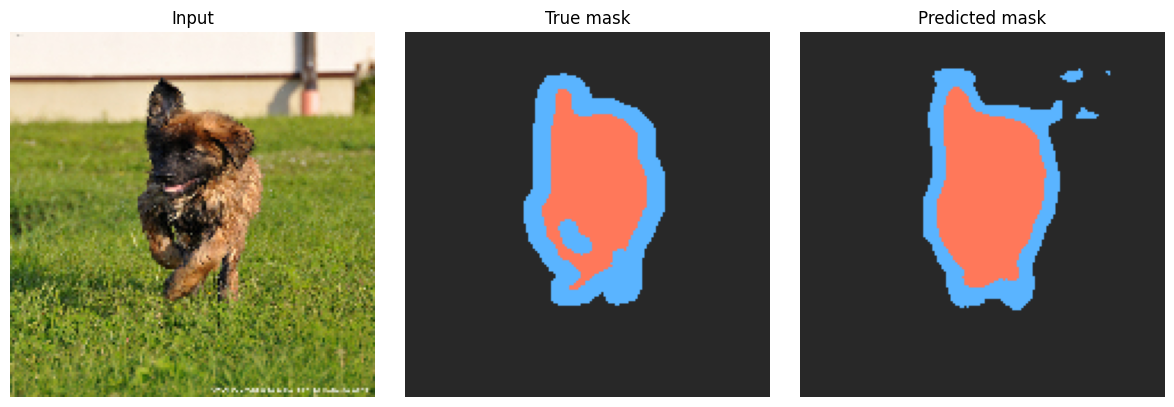

In [8]:
# Visualize predictions.
images, masks = next(iter(test_ds))
logits = best_segmenter.predict(images, verbose=0)
pred_masks = np.argmax(logits, axis=-1)

for i in range(4):
    show_segmentation_triplet(
        images[i].numpy(),
        masks[i].numpy(),
        pred_masks[i],
        PROJECT_ROOT / f"results/segmentation/mask_example_{i}.png",
    )

show_segmentation_triplet(
    images[0].numpy(),
    masks[0].numpy(),
    pred_masks[0],
    PROJECT_ROOT / "results/segmentation/mask_examples.png",
)